# Machin!!


In [170]:
import scanpy as sc
import os
import matplotlib.pyplot as plt

In [171]:
# Load as cells x genes (transpose because genes are rows in gut.tsv)
data = sc.read_text(os.getcwd() + "\\gut.tsv", delimiter="\t").T
data.var_names_make_unique()

In [174]:

n_cells_1 = data.n_obs
n_genes_1 = data.n_vars

In [175]:
#filters
sc.pp.filter_cells(data, min_genes=200) # filter low-quality cells
sc.pp.filter_genes(data, min_cells=100)  # filter rare genes

In [177]:
n_cells_2 = data.n_obs
n_genes_2 = data.n_vars
print(f"number of cells removed:{n_cells_1 - n_cells_2}")
print(f"number of genes removed:{n_genes_1 - n_genes_2}")

number of cells removed:0
number of genes removed:5618


In [185]:
sc.pp.calculate_qc_metrics(data, inplace=True)
n_cells_by_counts = data.var.n_cells_by_counts
mean_counts = data.var.mean_counts
total_counts = data.obs.total_counts

(array([11., 46., 53., 48., 35., 41., 42., 53., 49., 64., 58., 46., 58.,
        56., 71., 75., 69., 52., 59., 76., 74., 57., 60., 56., 59., 72.,
        52., 60., 60., 62., 64., 73., 52., 58., 65., 47., 77., 58., 71.,
        56., 53., 44., 77., 55., 49., 51., 70., 51., 58., 58., 61., 41.,
        53., 38., 42., 40., 44., 45., 40., 43., 51., 50., 40., 41., 30.,
        31., 35., 34., 33., 40., 40., 37., 51., 39., 37., 35., 25., 23.,
        37., 26., 33., 26., 35., 30., 25., 27., 26., 23., 33., 30., 25.,
        24., 27., 25., 30., 21., 25., 29., 30., 27., 15., 17., 17., 18.,
        15., 21., 18., 22., 12., 17., 18., 17.,  8., 16., 14., 10., 11.,
        10., 13., 14., 12., 23., 17., 15., 18.,  9., 15., 12., 11.,  8.,
        12., 11., 11.,  7., 10.,  8., 12., 12.,  7.,  9.,  8., 12.,  7.,
         5.,  4.,  6.,  8.,  3., 10.,  7.,  8.,  9., 12.,  8.,  3.,  6.,
         7.,  5.,  5.,  5.,  8.,  7.,  5.,  5.,  7.,  4.,  5.,  7.,  7.,
         8.,  8.,  2.,  6.,  2.,  3.,  5.,  6.,  6.

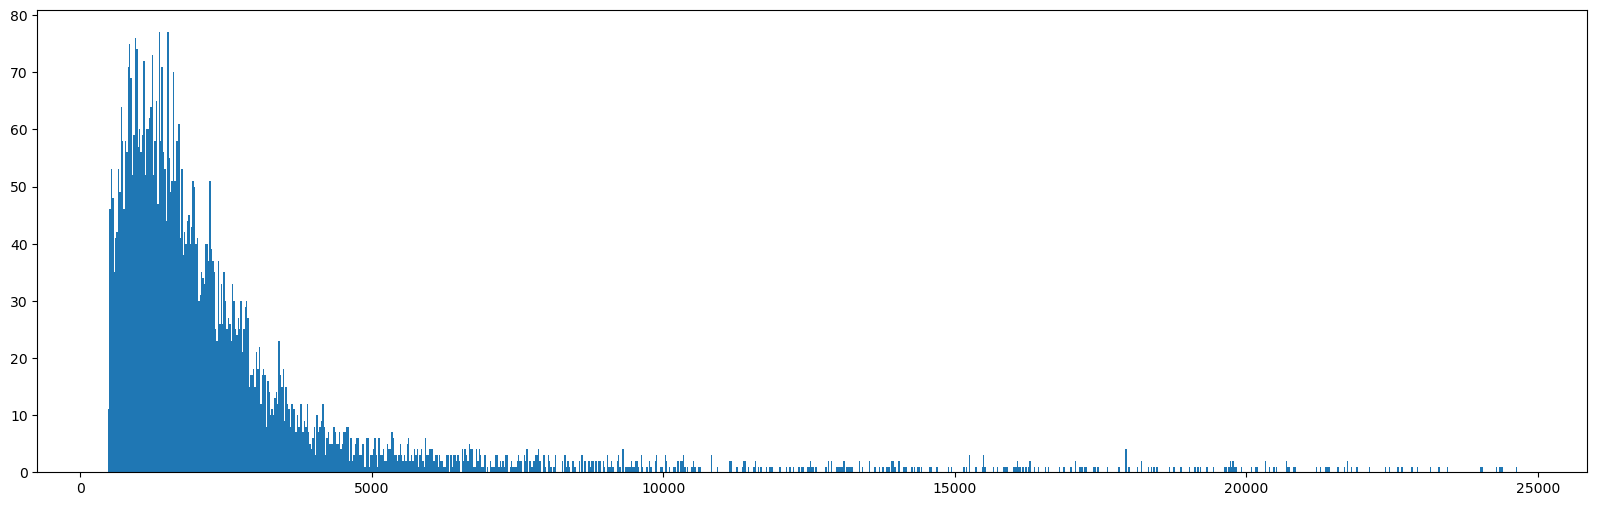

In [187]:
plt.hist(total_counts,bins = 1000)

In [ ]:
#normalizing the data 
sc.pp.normalize_total(data,target_sum=10000)
sc.pp.log1p(data)

In [ ]:
#clustering
sc.pp.pca(data)
sc.pp.neighbors(data)



In [ ]:
sc.tl.leiden(data,resolution=0.05)

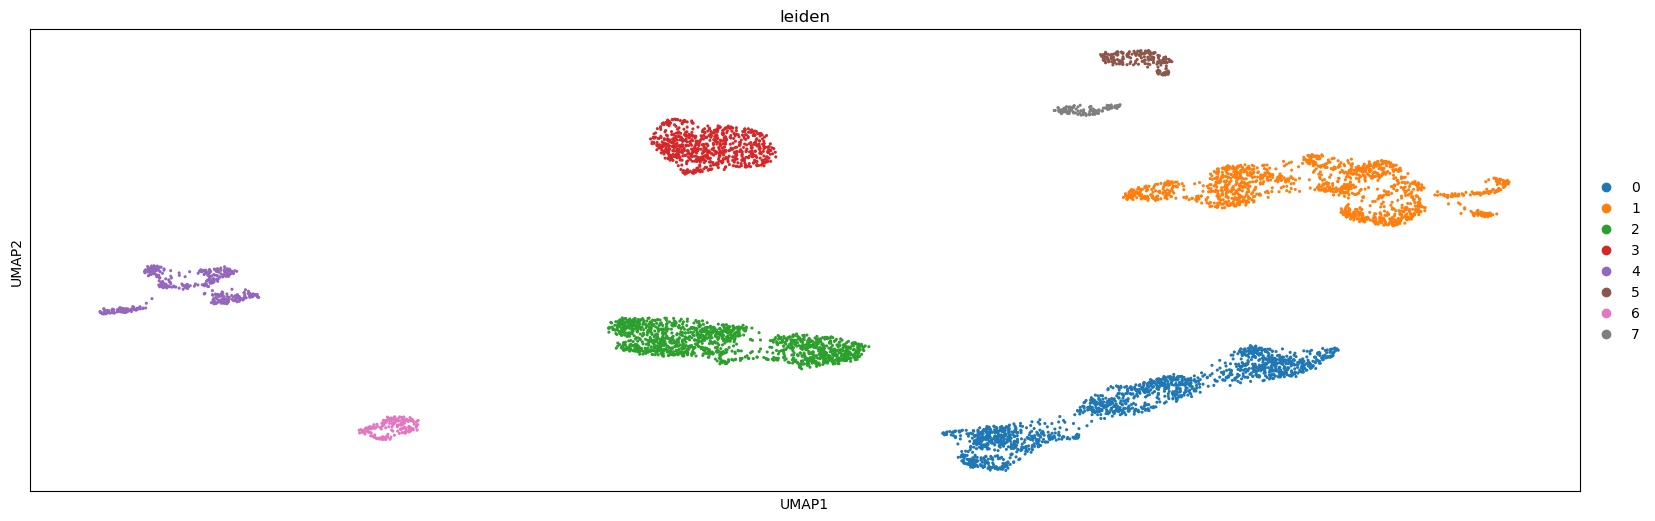

In [ ]:
#t-sne
sc.tl.umap(data)
#visulisation
sc.pl.umap(data,color = "leiden")

In [ ]:
sc.tl.rank_genes_groups(data, groupby="leiden")

In [ ]:
result = sc.get.rank_genes_groups_df(data,group = None)
clusters = result["group"].unique()
top_genes = []
for c in clusters:
    top_genes.append(result[result["group"] == c].sort_values(by = "logfoldchanges",ascending = False)["names"].iloc[0])

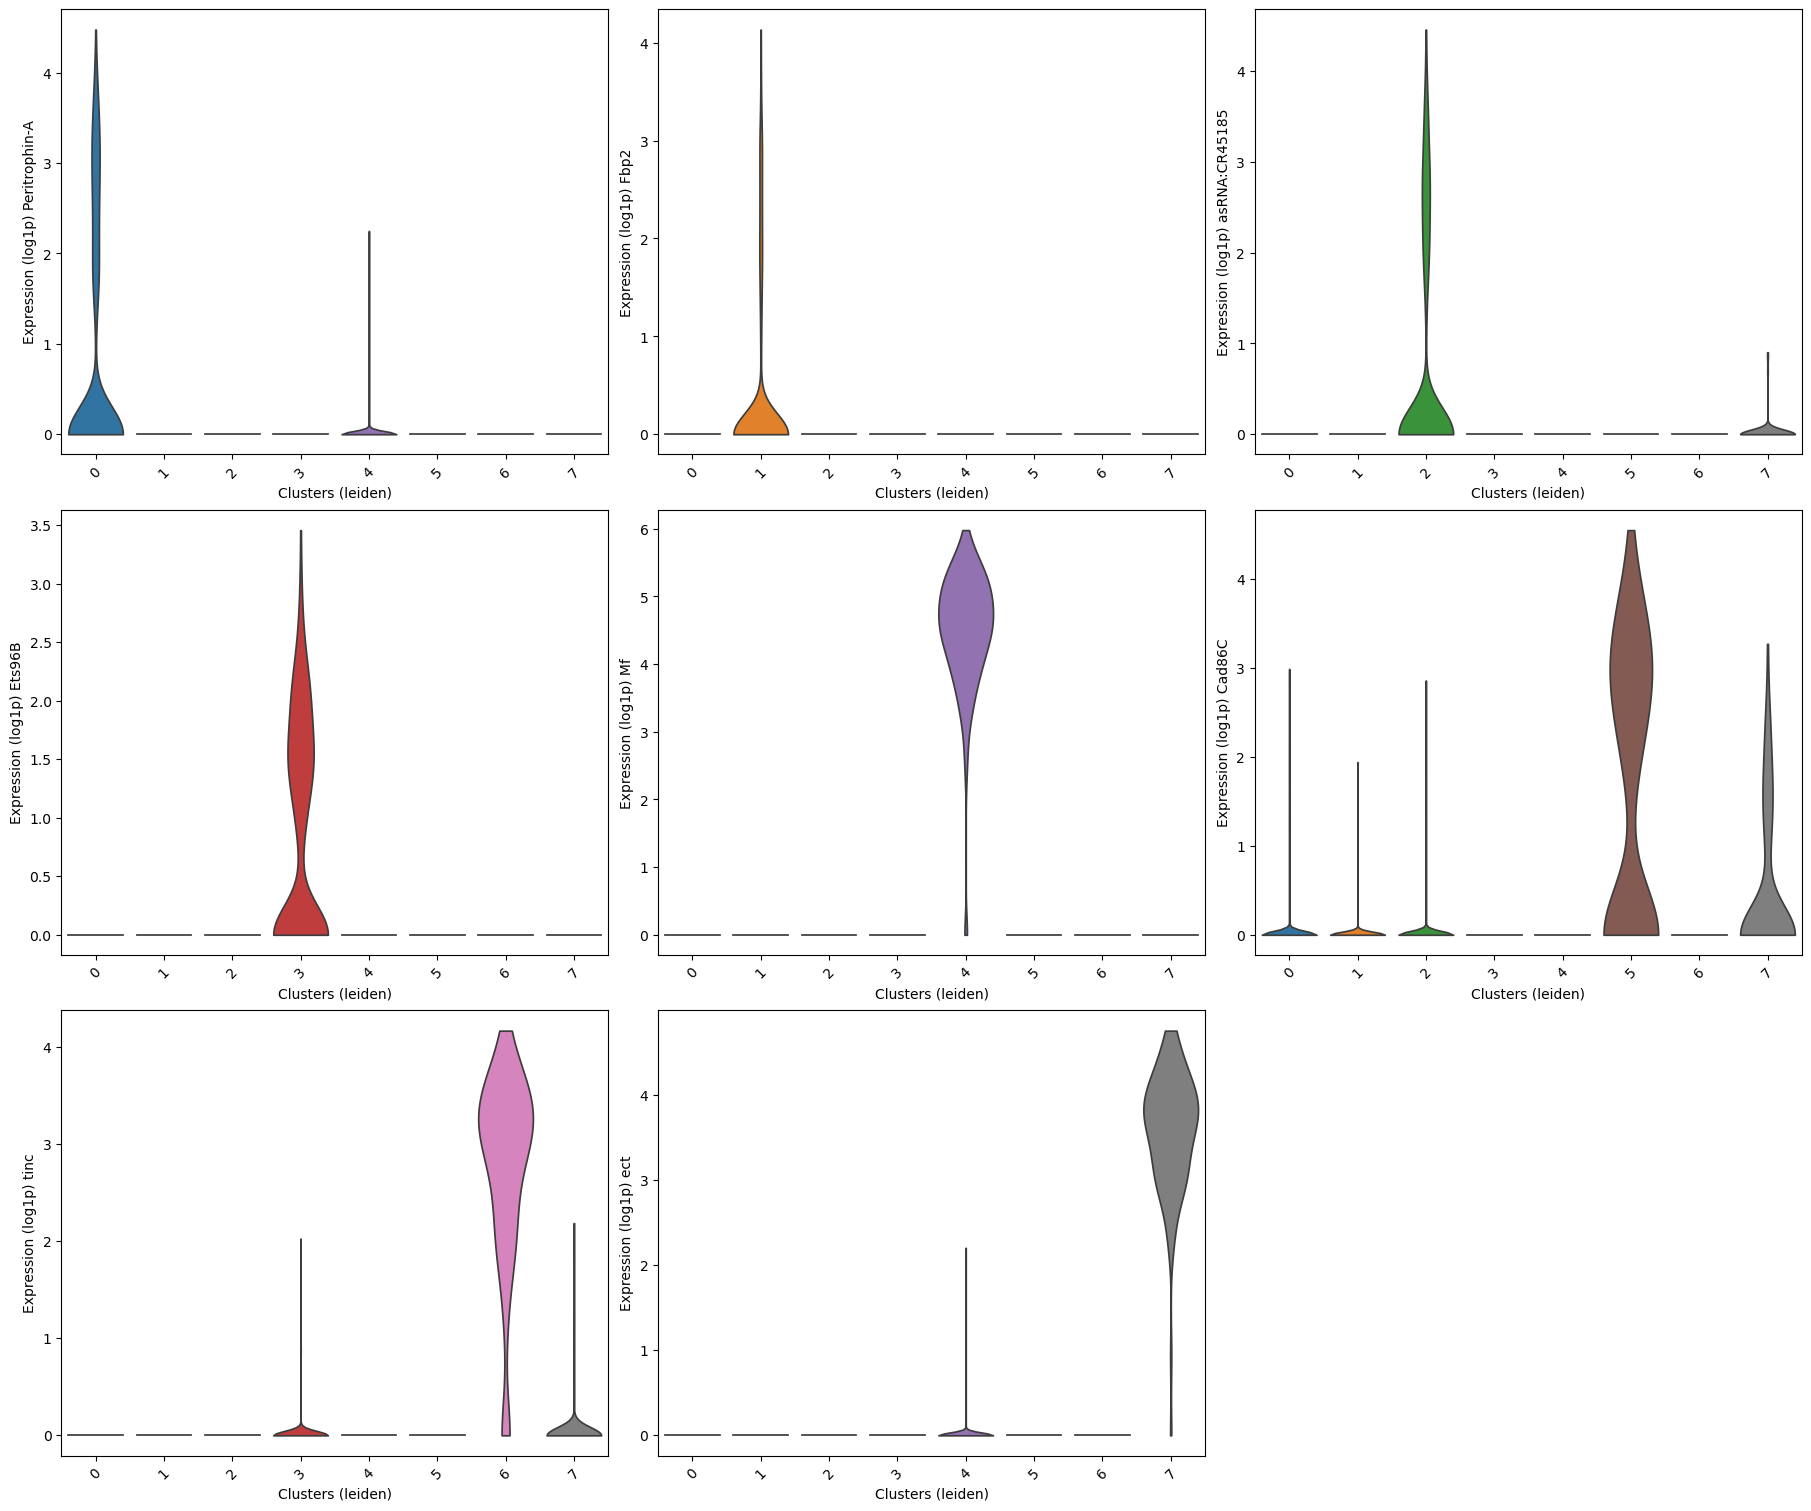

In [ ]:
ncols = 3
nrows = (len(top_genes) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows), constrained_layout=True)
axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

for i, gene in enumerate(top_genes):
    sc.pl.violin(
        data,
        keys=gene,
        groupby="leiden",
        ax=axes[i],
        show=False,
        stripplot=False,
        rotation=45
    )
    axes[i].set_ylabel("Expression (log1p)" + " " +gene)
    axes[i].set_xlabel("Clusters (leiden)")

for j in range(len(top_genes), len(axes)):
    axes[j].axis("off")

plt.show()

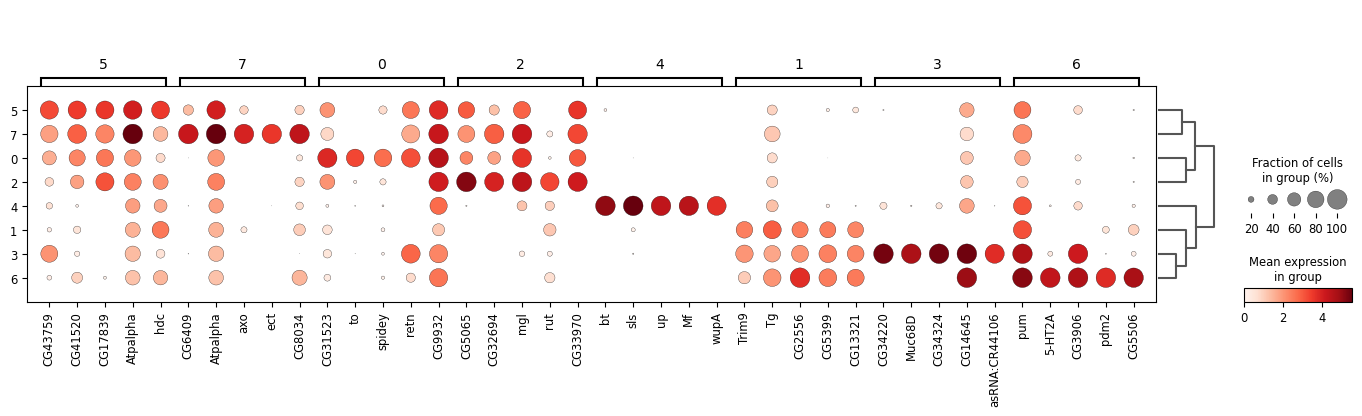

In [ ]:
sc.pl.rank_genes_groups_dotplot(data, n_genes=5)

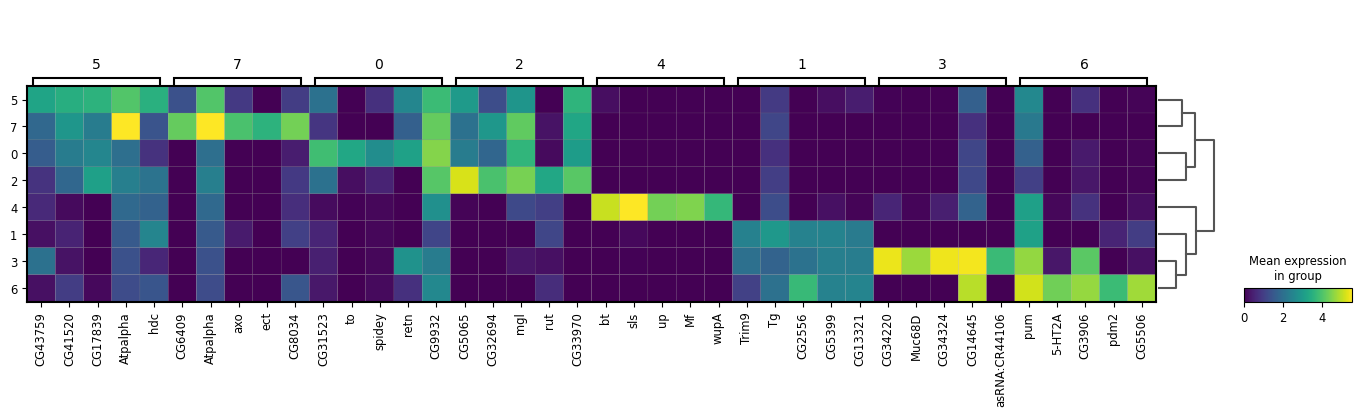

In [ ]:
sc.pl.rank_genes_groups_matrixplot(data, n_genes=5)